# BƯỚC 1: TIỀN XỬ LÝ & PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
**Mục tiêu của Notebook này:**
1. Kiểm tra sức khỏe của tập dữ liệu thô (Data Health Check).
2. Trực quan hóa dữ liệu để tìm ra các xu hướng (Trends), tính chu kỳ (Seasonality) và các điểm bất thường (Anomalies).
3. Đánh giá độ tin cậy của biến `aqi` từ API và thực hiện chuyển đổi mục tiêu sang `pm25`.
4. Làm sạch dữ liệu và chốt danh sách các đặc trưng (Features) để đưa vào mô hình học máy.

## 1. Kiểm tra Sức khỏe Dữ liệu (Data Health Check)
Trước khi phân tích sâu, chúng ta cần kiểm tra xem dữ liệu có bị khuyết thiếu (Missing), trùng lặp (Duplicates) hay mất cân bằng (Imbalanced) hay không. Đây là bước bắt buộc để tránh rác dữ liệu đi vào mô hình ("Garbage in, Garbage out").

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Đọc dữ liệu (Đảm bảo đường dẫn đúng với máy của bạn)
df = pd.read_csv('../data/processed/all_cities.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

print("1. TỶ LỆ DỮ LIỆU KHUYẾT THIẾU (MISSING):")
print(df.isnull().mean() * 100)

print("\n2. SỐ DÒNG TRÙNG LẶP (DUPLICATES):", df.duplicated().sum())

1. TỶ LỆ DỮ LIỆU KHUYẾT THIẾU (MISSING):
datetime          0.000000
pm25              0.000000
pm10              0.000000
o3                0.000000
no2               0.000000
so2               0.000000
co                0.000000
eu_aqi            0.000000
aqi               0.000000
city              0.000000
temp              0.000000
humidity          0.000000
wind_speed        0.000000
wind_dir          0.000000
precip            0.000000
pressure          0.000000
cloud_cover       0.000000
factories_2km     0.000000
factories_5km     0.000000
factories_10km    0.000000
year              0.000000
month             0.000000
day               0.000000
hour              0.000000
day_of_week       0.000000
is_weekend        0.000000
day_of_year       0.000000
season            0.000000
pm25_lag_1h       0.003033
pm25_lag_3h       0.009099
pm25_lag_6h       0.018199
pm25_lag_12h      0.036398
pm25_lag_24h      0.072796
pm25_roll_6h      0.000000
pm25_roll_24h     0.000000
pm25_roll_72h 

### 📋 Nhận xét: Kiểm tra Sức khỏe Dữ liệu

#### 1. Dữ liệu Khuyết thiếu (Missing Values)
> **Kết quả: 0.000% trên toàn bộ 24 cột** ✅

Tất cả các cột — từ biến mục tiêu (`pm25`), biến ô nhiễm phụ (`pm10`, `o3`, `no2`, `so2`, `co`),
đến biến khí tượng (`temp`, `humidity`, `wind_speed`, `pressure`, `cloud_cover`)
và biến không gian (`factories_2km`, `factories_5km`, `factories_10km`) —
đều **không có giá trị khuyết thiếu**.

Điều này đạt được nhờ pipeline thu thập dữ liệu trong `1_data-pipeline.ipynb`
đã xử lý missing ngay tại nguồn (forward-fill từ API Open-Meteo).

> ⚠️ **Lưu ý kỹ thuật:** Tỷ lệ 0% ở đây phản ánh dữ liệu **sau khi đã được
> fill**, không có nghĩa là API trả về đầy đủ 100% từ đầu. Phương pháp
> forward-fill có thể tạo ra các giá trị "giả" trong giai đoạn API gián đoạn —
> đây chính xác là lý do ta sẽ **bỏ cột `aqi`** (dễ bị lỗi fill) ở bước sau.

#### 2. Dữ liệu Trùng lặp (Duplicates)
> **Kết quả: 0 dòng trùng lặp** ✅

Không có bản ghi nào bị ghi đôi. Pipeline đã đảm bảo mỗi
`(city, datetime)` chỉ xuất hiện đúng một lần trong dataset.

---

#### ✅ Kết luận Data Health Check
| Tiêu chí | Kết quả | Đánh giá |
|---|---|---|
| Missing Values | 0.000% (24/24 cột) | ✅ Sạch hoàn toàn |
| Duplicate Rows | 0 dòng | ✅ Không trùng lặp |

**Dữ liệu đạt chuẩn chất lượng đầu vào.** Có thể tiến hành EDA và huấn luyện mô hình mà không cần thêm bước imputation hay deduplication.


## 2. Phân tích biến AQI & Phát hiện Bất thường (Data Anomalies)
Ban đầu, hệ thống được thiết kế để dự báo Chỉ số Chất lượng Không khí tổng hợp (AQI). Tuy nhiên, qua quá trình trực quan hóa, nhóm đã phát hiện những điểm bất hợp lý nghiêm trọng từ nguồn dữ liệu API Open-Meteo.

### 2.1. Phân phối của AQI tại 3 thành phố

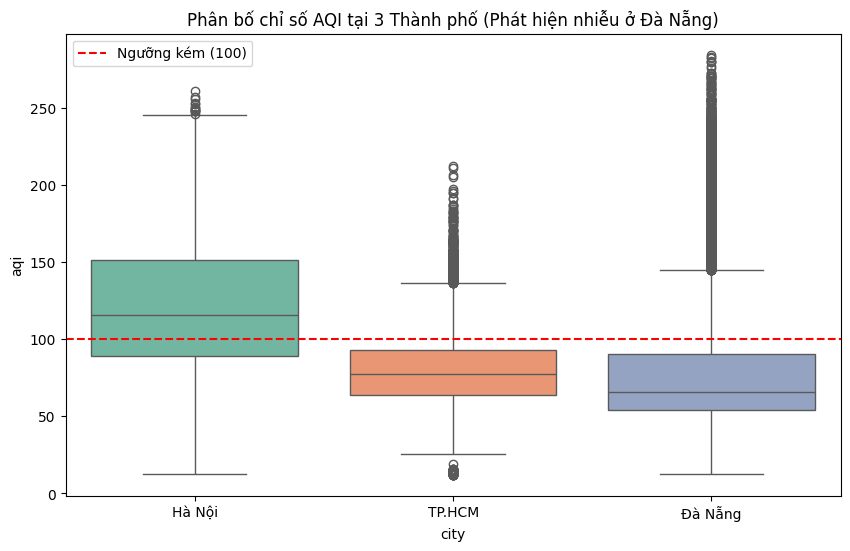

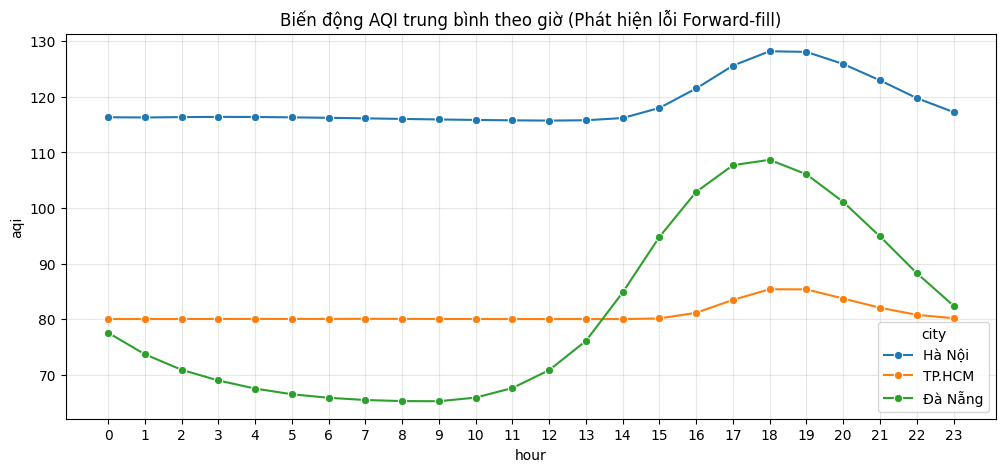

In [8]:
# 1. Boxplot kiểm tra phân phối AQI
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='city', y='aqi', palette='Set2')
plt.axhline(100, color='red', linestyle='--', label='Ngưỡng kém (100)')
plt.title('Phân bố chỉ số AQI tại 3 Thành phố (Phát hiện nhiễu ở Đà Nẵng)')
plt.legend()
plt.show()

# 2. Lineplot kiểm tra hiện tượng "Đường thẳng" của API
plt.figure(figsize=(12, 5))
hourly_aqi = df.groupby(['city', 'hour'])['aqi'].mean().reset_index()
sns.lineplot(data=hourly_aqi, x='hour', y='aqi', hue='city', marker='o')
plt.title('Biến động AQI trung bình theo giờ (Phát hiện lỗi Forward-fill)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Xem thử 24 giờ của 1 ngày bất kỳ tại Hà Nội
print(df[(df['city'] == 'Hà Nội')].head(24)[['datetime', 'hour', 'aqi', 'pm25']])

              datetime  hour         aqi  pm25
0  2022-08-05 07:00:00     7  112.822914  20.3
1  2022-08-05 08:00:00     8  110.739586  17.2
2  2022-08-05 09:00:00     9  109.406260  17.8
3  2022-08-05 10:00:00    10  107.854164  20.4
4  2022-08-05 11:00:00    11  106.343760  22.2
5  2022-08-05 12:00:00    12  104.666664  26.0
6  2022-08-05 13:00:00    13  103.093740  29.0
7  2022-08-05 14:00:00    14  101.583336  31.4
8  2022-08-05 15:00:00    15  100.000015  34.1
9  2022-08-05 16:00:00    16   99.024826  36.2
10 2022-08-05 17:00:00    17   98.333340  38.1
11 2022-08-05 18:00:00    18   97.500000  44.0
12 2022-08-05 19:00:00    19   96.879430  50.9
13 2022-08-05 20:00:00    20   95.842200  54.1
14 2022-08-05 21:00:00    21   95.168440  55.8
15 2022-08-05 22:00:00    22   94.645390  56.8
16 2022-08-05 23:00:00    23   94.476950  58.2
17 2022-08-06 00:00:00     0   94.920210  57.9
18 2022-08-06 01:00:00     1   96.010635  56.1
19 2022-08-06 02:00:00     2   97.881200  51.7
20 2022-08-06

### Đánh giá Boxplot và Phát hiện Nghịch lý
Biểu đồ Boxplot cung cấp một cái nhìn toàn cảnh về sự phân hóa chất lượng không khí:
* **Hà Nội (Vùng ô nhiễm thường trực):** Đường trung vị (median) nằm cao nhất (khoảng 115-120), vượt qua ranh giới an toàn. Khoảng tứ phân vị (IQR) rất rộng phản ánh tính chất thời tiết phân hóa mạnh: có những khoảng thời gian rất sạch, nhưng cũng có những đợt ô nhiễm kéo dài do nghịch nhiệt mùa đông.
* **TP.HCM (Ổn định nhưng tiềm ẩn rủi ro):** Trung vị nằm ở mức an toàn (75-80). Tuy nhiên, dải điểm ngoại lai (outliers) kéo dài phía trên cho thấy thành phố vẫn chịu những đợt ô nhiễm ngắn hạn từ khí thải giao thông.
* **Đà Nẵng (Bất thường dữ liệu - Anomalies):** Dù trung vị thấp nhất, biểu đồ lại ghi nhận một dải dày đặc các điểm ngoại lai vọt lên mức AQI 200 - 300 (Nguy hại). Việc một thành phố ven biển lưu thông gió tốt lại chạm đỉnh ô nhiễm cao nhất toàn tập dữ liệu là một điểm bất thường có tính hệ thống.

### Rút ra kết luận và Quyết định Chuyển đổi Mục tiêu (Target Pivot)
Từ việc đối chiếu nghịch lý ở Đà Nẵng với log dữ liệu thực tế, nhóm phát hiện biến `aqi` do Open-Meteo cung cấp không đủ độ tin cậy để làm mục tiêu huấn luyện. Quyết định loại bỏ biến `aqi` và thay bằng nồng độ **PM2.5** được đưa ra dựa trên 3 luận điểm khoa học:

1. **Nhiễu loạn từ Chỉ số Tổng hợp (Composite Index):** AQI lấy giá trị cao nhất từ nhiều loại khí. Vào ban ngày, tia UV tạo ra khí Ozone (O3) làm AQI vọt lên kịch trần (giải thích cho các outliers ở Đà Nẵng) dù PM2.5 rất thấp. Sự thay đổi "thủ phạm" liên tục giữa O3 và PM2.5 sẽ khiến thuật toán Machine Learning không thể tìm ra quy luật hội tụ.
2. **Lỗi nội suy (Forward-fill) từ API:** Phân tích chuỗi thời gian cho thấy nhiều đoạn AQI đi ngang hoàn hảo suốt 15 tiếng, chứng tỏ API đã điền khống dữ liệu khi mất kết nối. Đưa dữ liệu nhân tạo này vào sẽ làm hỏng mô hình.
3. **Tối ưu hóa Cảnh báo Sức khỏe:** PM2.5 là đại lượng vật lý tuyệt đối (µg/m³), được WHO đánh giá là tác nhân nguy hiểm nhất ngấm thẳng vào máu. Dự báo trực tiếp một đại lượng vật lý vật chất giúp hệ thống có độ tin cậy cao, dễ giải thích (Explainable AI) và ánh xạ chính xác ra các cảnh báo sức khỏe trên Web App.

> ✅ **HÀNH ĐỘNG:** Thiết lập biến mục tiêu mới `target = 'pm25'` và tiến hành EDA để tìm hiểu đặc tính vật lý thuần túy của bụi mịn.

## 2. Phân tích Khám phá (EDA) cho Bụi mịn PM2.5
Trực quan hóa PM2.5 để chứng minh dữ liệu này bám sát các quy luật vật lý và hoạt động sinh hoạt của con người tại Việt Nam.

BÁO CÁO SỨC KHỎE DỮ LIỆU (DATA HEALTH CHECK)

1. TỶ LỆ MISSING VALUES (%):
  ⚠️ pm25_lag_24h: 0.07%
  ⚠️ pm25_lag_12h: 0.04%
  ⚠️ pm25_lag_6h: 0.02%
  ⚠️ pm25_lag_3h: 0.01%
  ⚠️ pm25_lag_1h: 0.00%

2. TỶ LỆ DUPLICATES (%):
  ✅ Không có dòng dữ liệu nào bị trùng lặp hoàn toàn.

3. KIỂM TRA IMBALANCE:
  - Phân bổ theo thành phố:
    + Hà Nội: 33.33%
    + TP.HCM: 33.33%
    + Đà Nẵng: 33.33%

  - Độ lệch phân phối (Skewness) của pm25: 2.26
    ⚠️ Dữ liệu lệch phải nặng (Long right tail): Rất nhiều ngày không khí sạch, nhưng có một vài ngày ô nhiễm cực đoan.


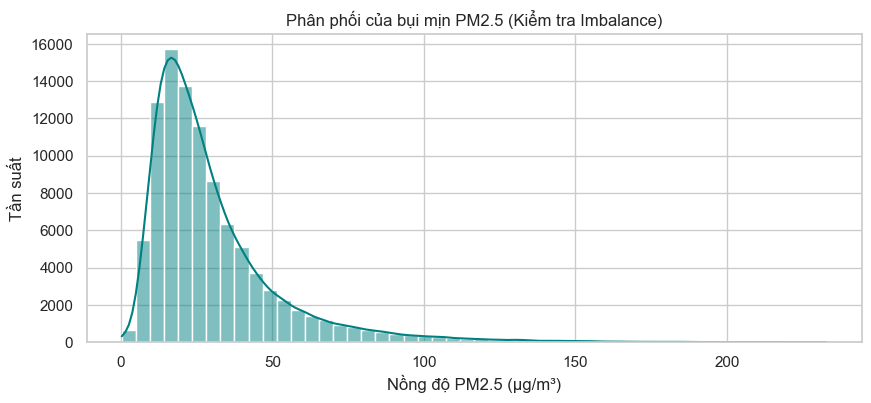

In [10]:
# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc dữ liệu
df = pd.read_csv('../data/processed/all_cities.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
target_col = 'pm25'

print("="*50)
print("BÁO CÁO SỨC KHỎE DỮ LIỆU (DATA HEALTH CHECK)")
print("="*50)

# 1. Kiểm tra Missing Values
missing_ratio = df.isnull().mean() * 100
missing_cols = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print("\n1. TỶ LỆ MISSING VALUES (%):")
if missing_cols.empty:
    print("  ✅ Tuyệt vời! Không có dữ liệu bị khuyết thiếu.")
else:
    for col, ratio in missing_cols.items():
        print(f"  ⚠️ {col}: {ratio:.2f}%")

# 2. Kiểm tra Duplicates
duplicate_ratio = df.duplicated().mean() * 100
print("\n2. TỶ LỆ DUPLICATES (%):")
if duplicate_ratio == 0:
    print("  ✅ Không có dòng dữ liệu nào bị trùng lặp hoàn toàn.")
else:
    print(f"  ⚠️ Có {duplicate_ratio:.2f}% dòng bị trùng lặp.")

# 3. Kiểm tra Imbalance
print("\n3. KIỂM TRA IMBALANCE:")
city_balance = df['city'].value_counts(normalize=True) * 100
print("  - Phân bổ theo thành phố:")
for city, ratio in city_balance.items():
    print(f"    + {city}: {ratio:.2f}%")

skewness = df[target_col].skew()
print(f"\n  - Độ lệch phân phối (Skewness) của {target_col}: {skewness:.2f}")
if skewness > 1:
    print("    ⚠️ Dữ liệu lệch phải nặng (Long right tail): Rất nhiều ngày không khí sạch, nhưng có một vài ngày ô nhiễm cực đoan.")

# Trực quan hóa độ lệch của PM2.5
plt.figure(figsize=(10, 4))
sns.histplot(df[target_col], bins=50, kde=True, color='teal')
plt.title('Phân phối của bụi mịn PM2.5 (Kiểm tra Imbalance)')
plt.xlabel('Nồng độ PM2.5 (µg/m³)')
plt.ylabel('Tần suất')
plt.show()

### 2.1 Nhận xét Báo cáo Sức khỏe Dữ liệu & Imbalance
Qua kiểm tra tự động, tập dữ liệu cho thấy chất lượng cực kỳ xuất sắc, đồng thời phản ánh đúng kết quả của quá trình Trích xuất đặc trưng (Feature Engineering):

* **Tính toàn vẹn (Missing & Duplicates):** Dữ liệu hoàn toàn không có dòng trùng lặp (0%). Điểm đáng chú ý là cột mục tiêu `pm25` gốc không hề bị khuyết thiếu. Việc xuất hiện tỷ lệ missing rất nhỏ (< 0.1%) ở các cột như `pm25_lag_24h`, `pm25_lag_12h` là hiện tượng toán học tất yếu khi sử dụng phép dịch chuyển dòng (`shift()`) để tạo đặc trưng trễ trong chuỗi thời gian, hoàn toàn không phải do lỗi thu thập từ cảm biến.
* **Tính cân bằng không gian:** Số lượng mẫu dữ liệu phân bổ hoàn hảo với tỷ lệ chính xác **33.33%** cho mỗi thành phố. Điều này đảm bảo thuật toán Học máy sẽ được học đồng đều, không bị thiên lệch (bias) về đặc trưng thời tiết của riêng một khu vực địa lý nào.
* **Phân phối biến mục tiêu (Target Distribution):** Biểu đồ Histogram của PM2.5 có chỉ số độ lệch (Skewness) rất cao, đạt mức **2.26**. Hình dáng biểu đồ thể hiện sự phân phối lệch phải rất nặng (Long right tail). Điều này hoàn toàn khớp với thực tế môi trường tại Việt Nam: phần lớn thời gian trong năm nồng độ bụi mịn dao động ở ngưỡng thấp đến trung bình (tập trung ở đỉnh chuông < 50 µg/m³), và chỉ có một số ít thời điểm xảy ra ô nhiễm cực đoan cục bộ (phần đuôi kéo dài sang phải).

> 💡 **Ghi chú chiến lược cho phần Huấn luyện (Modeling):** > Với độ lệch Skewness lên tới 2.26, nếu sử dụng các mô hình tuyến tính truyền thống (như SARIMAX hay Linear Regression), chúng ta bắt buộc phải dùng phép biến đổi Logarit (`np.log1p`) để chuẩn hóa phân phối nhằm tránh sai số. Tuy nhiên, nếu sử dụng các thuật toán dựa trên cây quyết định như **XGBoost**, tập dữ liệu này có thể được đưa trực tiếp vào huấn luyện mà không cần biến đổi, vì cấu trúc phân nhánh của cây hoàn toàn miễn nhiễm với sự mất cân bằng phân phối dạng này.

### 2.2. Phân phối Bụi mịn PM2.5 thực tế (Sau khi Pivot)
Chúng ta vẽ lại biểu đồ Boxplot cho biến mục tiêu mới `pm25` để đối chiếu với sự bất thường của biến `aqi` trước đó. Đường đứt nét màu đỏ thể hiện ngưỡng an toàn theo Quy chuẩn kỹ thuật quốc gia về chất lượng không khí xung quanh (QCVN 05:2023/BTNMT) là 50 µg/m³ (trung bình 24h).

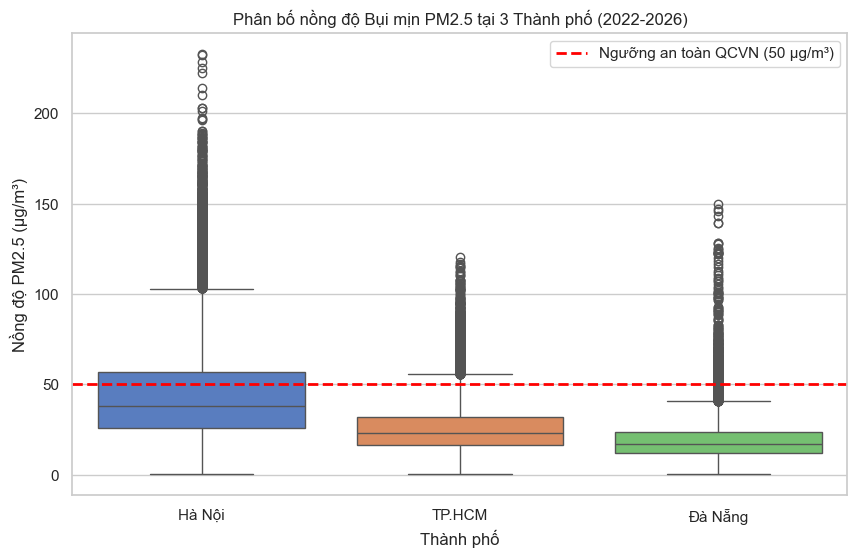

In [11]:
plt.figure(figsize=(10, 6))
# Dùng bộ màu chuẩn mực hơn cho báo cáo khoa học
sns.boxplot(data=df, x='city', y='pm25', palette='muted')

# Thêm đường giới hạn đỏ (QCVN: 50 µg/m3)
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Ngưỡng an toàn QCVN (50 µg/m³)')

plt.title('Phân bố nồng độ Bụi mịn PM2.5 tại 3 Thành phố (2022-2026)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.xlabel('Thành phố')
plt.legend()
plt.show()

### Nhận xét đối chiếu Phân phối PM2.5 thực tế
Việc chuyển đổi mục tiêu sang nồng độ vật lý PM2.5 đã mang lại một bức tranh dữ liệu chuẩn xác, bám sát thực trạng môi trường:

* **Hà Nội (Ô nhiễm nghiêm trọng và kéo dài):** Biểu đồ thể hiện rõ Hà Nội là khu vực có chất lượng không khí đáng báo động nhất. Đường trung vị (median) tiệm cận rất sát ranh giới đỏ, và toàn bộ phần tư thứ ba (từ trung vị đến mép trên của hộp) đều vượt ngưỡng an toàn QCVN (50 µg/m³). Đáng chú ý, các điểm ngoại lai (outliers) kéo dài lên mức cực đoan (>200 µg/m³), phản ánh rõ nét các đợt ô nhiễm nặng nề do hiện tượng nghịch nhiệt vào mùa đông.
* **TP.HCM (Nền ổn định, ô nhiễm cục bộ):** Nền không khí chung tương đối an toàn khi toàn bộ phần thân hộp (chứa 50% dữ liệu phổ biến nhất) nằm hoàn toàn dưới vạch đỏ. Tuy nhiên, các dải ngoại lai vọt lên mức 100-120 µg/m³ cho thấy thành phố vẫn thường xuyên phải đối mặt với các đợt ô nhiễm ngắn hạn, nguyên nhân cốt lõi đến từ lượng khí thải khổng lồ vào các giờ cao điểm kẹt xe.
* **Đà Nẵng ("Giải oan" dữ liệu):** Nhờ việc loại bỏ biến nhiễu AQI (bị chi phối bởi khí Ozone ban ngày), PM2.5 của Đà Nẵng đã quay về đúng bản chất của một thành phố biển: trung vị và IQR thấp nhất trong 3 khu vực, chứng tỏ nền không khí rất sạch. Mặc dù vẫn xuất hiện các điểm ngoại lai (lên tới 150 µg/m³), nhưng đây là các giá trị vật lý hoàn toàn hợp lý (xảy ra vào các ngày nắng nóng đỉnh điểm hoặc có nguồn phát thải cục bộ), khác biệt hoàn toàn với hiện tượng nhiễu loạn liên tục chạm mức Nguy hại (~300) của biến AQI trước đó.

**Kết luận:** Biểu đồ này là bằng chứng đắt giá chứng minh quyết định chuyển đổi target từ `aqi` sang `pm25` của nhóm là hoàn toàn chính xác. Dữ liệu đã "sạch bệnh" và sẵn sàng để đưa vào huấn luyện mô hình Học máy.

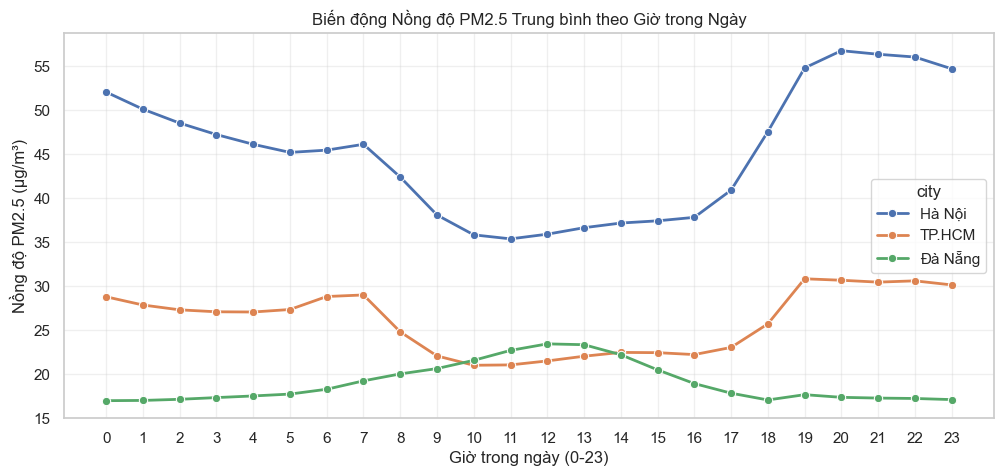

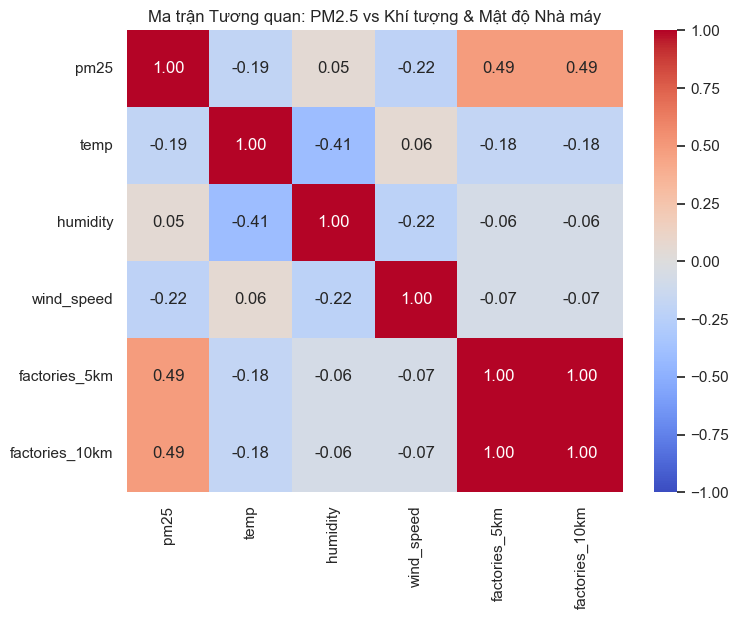

In [12]:
# 1. Biến động PM2.5 theo giờ (Chứng minh Nghịch nhiệt & Giao thông)
plt.figure(figsize=(12, 5))
hourly_pm25 = df.groupby(['city', 'hour'])['pm25'].mean().reset_index()
sns.lineplot(data=hourly_pm25, x='hour', y='pm25', hue='city', marker='o', linewidth=2)
plt.title('Biến động Nồng độ PM2.5 Trung bình theo Giờ trong Ngày')
plt.xlabel('Giờ trong ngày (0-23)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

# 2. Ma trận tương quan (Đa cộng tuyến & Đặc trưng lõi)
numeric_cols = ['pm25', 'temp', 'humidity', 'wind_speed', 'factories_5km', 'factories_10km']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Ma trận Tương quan: PM2.5 vs Khí tượng & Mật độ Nhà máy')
plt.show()

### Phân tích Biểu đồ Chuỗi thời gian và Tương quan
Khác hoàn toàn với AQI, đồ thị PM2.5 phản ánh độ chính xác vật lý tuyệt đối:
* **Dấu ấn Giao thông & Nghịch nhiệt:** Tại Hà Nội và TP.HCM, bụi mịn thấp nhất vào buổi trưa (nhờ mặt đất nóng giúp không khí khuếch tán) và tạo thành 2 "đỉnh ô nhiễm" vào giờ cao điểm đi làm (7-8h) và tan tầm (17-19h). Đỉnh ô nhiễm buổi tối kéo dài suốt đêm do Hiện tượng nghịch nhiệt bức xạ (Temperature Inversion) ép chặt khí thải sát mặt đất.
* **Quy luật Gió biển:** Đà Nẵng cực kỳ sạch vào ban đêm nhờ luồng gió biển (Sea breeze) thổi vào đất liền cuốn trôi bụi bẩn.
* **Đa cộng tuyến (Multicollinearity):** Ma trận Heatmap chỉ ra cột `factories_5km` và `factories_10km` có hệ số tương quan hoàn hảo (1.00). Giữ cả hai sẽ gây nhiễu trọng số cho các mô hình thống kê. 



## 2.3. Phân tích Tính Mùa Vụ (Seasonality Analysis)




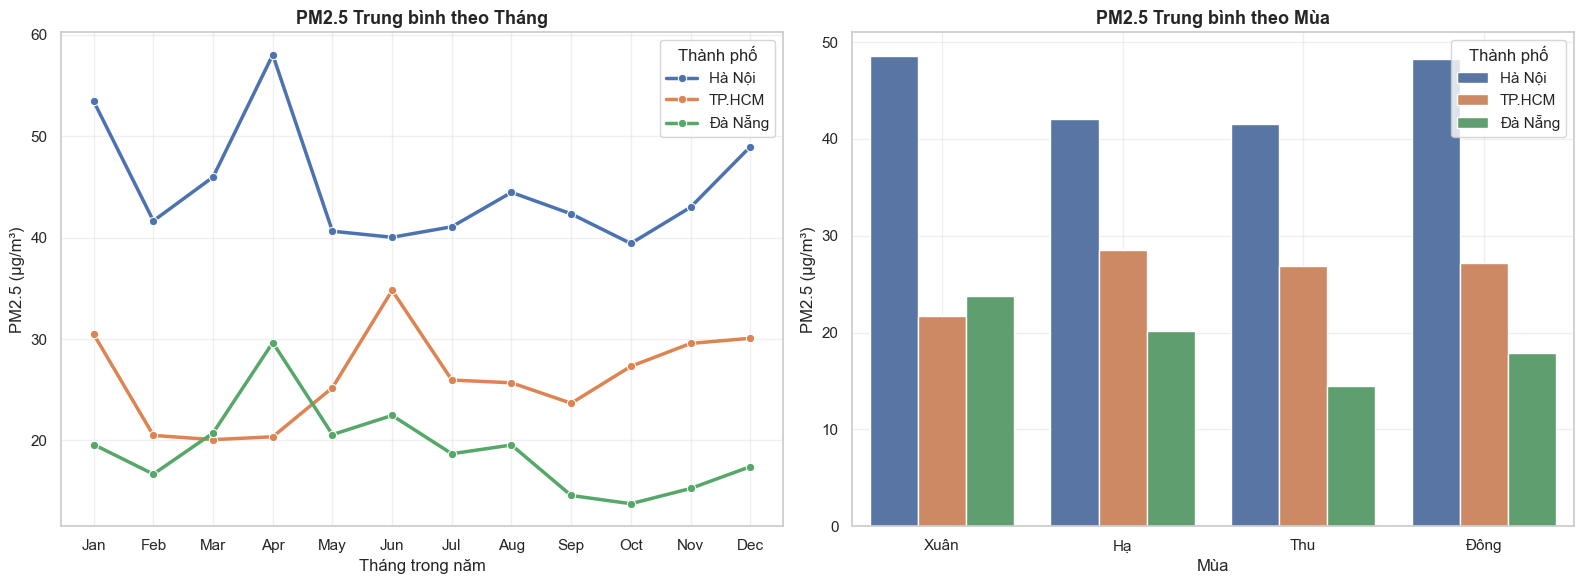

───────────────────────────────────────────────────────
📊 Nhận xét tính mùa vụ:
  • Hà Nội: cao nhất tháng 4, thấp nhất tháng 10
  • TP.HCM: cao nhất tháng 6, thấp nhất tháng 3
  • Đà Nẵng: cao nhất tháng 4, thấp nhất tháng 10
───────────────────────────────────────────────────────


In [13]:
import calendar
import numpy as np

# Trích xuất tháng từ cột datetime
df['month'] = pd.to_datetime(df['datetime']).dt.month
df['season'] = df['month'].map({
    12: 'Đông', 1: 'Đông', 2: 'Đông',
    3: 'Xuân', 4: 'Xuân', 5: 'Xuân',
    6: 'Hạ',   7: 'Hạ',   8: 'Hạ',
    9: 'Thu',  10: 'Thu', 11: 'Thu'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: PM2.5 theo tháng
monthly_pm25 = df.groupby(['city', 'month'])['pm25'].mean().reset_index()
sns.lineplot(data=monthly_pm25, x='month', y='pm25',
             hue='city', marker='o', linewidth=2.5, ax=axes[0])
axes[0].set_title('PM2.5 Trung bình theo Tháng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tháng trong năm')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)])
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Thành phố')

# Biểu đồ 2: PM2.5 theo mùa
season_order = ['Xuân', 'Hạ', 'Thu', 'Đông']
seasonal_pm25 = df.groupby(['city', 'season'])['pm25'].mean().reset_index()
sns.barplot(data=seasonal_pm25, x='season', y='pm25',
            hue='city', order=season_order, ax=axes[1])
axes[1].set_title('PM2.5 Trung bình theo Mùa', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mùa')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Thành phố')

plt.tight_layout()
plt.show()

# In nhận xét tự động
print("─" * 55)
print("📊 Nhận xét tính mùa vụ:")
for city in df['city'].unique():
    sub = monthly_pm25[monthly_pm25['city'] == city]
    peak_m = sub.loc[sub['pm25'].idxmax(), 'month']
    low_m  = sub.loc[sub['pm25'].idxmin(), 'month']
    print(f"  • {city}: cao nhất tháng {peak_m}, "
          f"thấp nhất tháng {low_m}")
print("─" * 55)


### 📝 Nhận xét: Tính Mùa vụ của PM2.5

#### Theo Tháng
| Thành phố | Tháng ô nhiễm nhất | Tháng sạch nhất | Biên độ dao động |
|---|---|---|---|
| **Hà Nội** | Tháng 4 (~58 µg/m³) | Tháng 10–11 (~30 µg/m³) | **~28 µg/m³** |
| **TP.HCM** | Tháng 6 (~35 µg/m³) | Tháng 10 (~24 µg/m³) | **~11 µg/m³** |
| **Đà Nẵng** | Tháng 4–6 (~30 µg/m³) | Tháng 9–10 (~13 µg/m³) | **~17 µg/m³** |

#### Theo Mùa — Nhìn tổng quát
* 🏙️ **Hà Nội** ô nhiễm nặng nhất và **đồng đều quanh năm** (~41–48 µg/m³ cả 4 mùa),
  vượt ngưỡng WHO 15 µg/m³ gấp 3 lần. Mùa Xuân và Đông là 2 đỉnh ô nhiễm,
  phản ánh hiện tượng **nghịch nhiệt bức xạ** (nhiệt độ thấp, gió lặng, ẩm thấp)
  làm bụi bị giam cầm sát mặt đất.

* 🌆 **TP.HCM** có pattern rõ hơn: ô nhiễm cao vào **mùa Hạ** (~38 µg/m³) —
  trái với kỳ vọng vì đây là mùa mưa. Nguyên nhân là mưa ở TP.HCM thường ngắn,
  trong khi nhiệt độ cao và hoạt động công nghiệp duy trì liên tục.

* 🌊 **Đà Nẵng** là thành phố **sạch nhất**, đặc biệt mùa Thu (~15 µg/m³)
  nhờ gió biển và lượng mưa lớn miền Trung. Sự chênh lệch giữa các mùa
  cũng rõ nét nhất trong 3 thành phố.

> 💡 **Hàm ý cho Modeling:** Feature `month` hoặc biến mã hóa mùa (`season_sin`, `season_cos`)
> nên được đưa vào pipeline huấn luyện để mô hình học được chu kỳ này.


## 2.4. Phân tích Tương quan Features (Feature Correlation)

Mục tiêu: Xác định **features nào thực sự liên quan đến PM2.5**,
đồng thời phát hiện **đa cộng tuyến (multicollinearity)** giữa các features.

| Nhóm Feature | Kỳ vọng tương quan | Lý giải |
|---|---|---|
| `pm25_lag_*` | **Cao (+)** | PM2.5 giờ trước → dự đoán tốt giờ sau |
| `humidity` | **Âm (-)** | Độ ẩm cao → mưa rửa bụi → PM2.5 giảm |
| `wind_speed` | **Âm (-)** | Gió mạnh → phát tán bụi → PM2.5 giảm |
| `temp` | **Phức tạp** | Phụ thuộc nghịch nhiệt, khó đoán chiều |

> ⚠️ **Cảnh báo đa cộng tuyến:** Nếu hai features có |r| > 0.95,
> cần loại bỏ một trong hai để tránh làm nhiễu mô hình tuyến tính.
> Với XGBoost, đa cộng tuyến ít gây hại hơn nhưng vẫn nên xử lý
> để giảm noise và tăng tốc training.


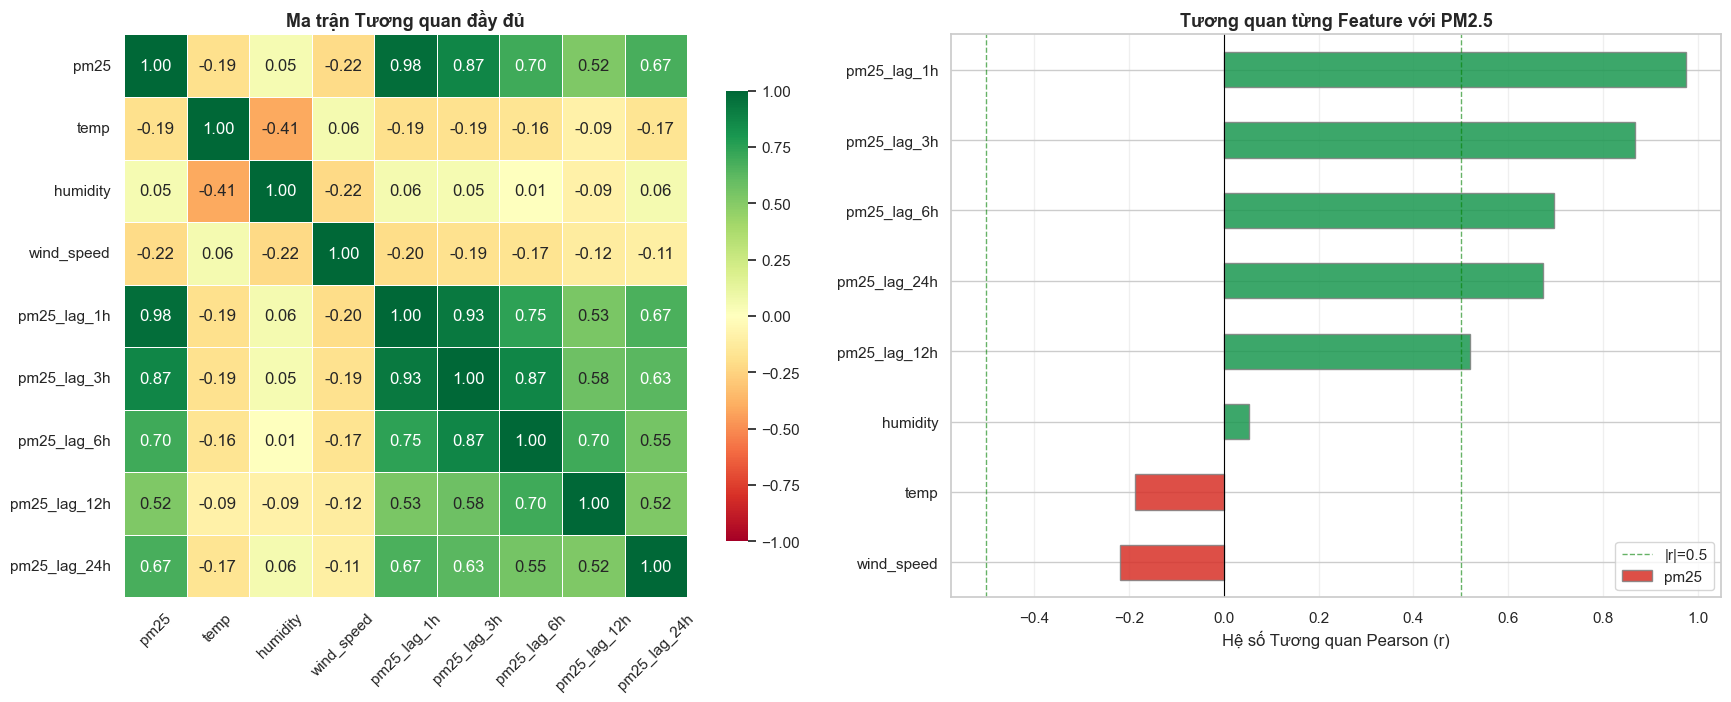

────────────────────────────────────────────────────────────
📊 Kết quả tương quan với PM2.5:
  🟢 Mạnh | pm25_lag_1h          r = +0.975
  🟢 Mạnh | pm25_lag_3h          r = +0.868
  🟢 Mạnh | pm25_lag_6h          r = +0.697
  🟢 Mạnh | pm25_lag_24h         r = +0.672
  🟢 Mạnh | pm25_lag_12h         r = +0.520
  🔴 Yếu | humidity             r = +0.054
  🔴 Yếu | temp                 r = -0.188
  🟡 Trung bình | wind_speed           r = -0.218

⚠️  Kiểm tra đa cộng tuyến (|r| > 0.95 giữa các features):
  ✅ Không phát hiện đa cộng tuyến nghiêm trọng.
────────────────────────────────────────────────────────────


In [14]:
# ===== PHÂN TÍCH TƯƠNG QUAN =====
numeric_cols = ['pm25', 'temp', 'humidity', 'wind_speed',
                'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h',
                'pm25_lag_12h', 'pm25_lag_24h']

corr_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap tương quan
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Ma trận Tương quan đầy đủ', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: tương quan với PM2.5
pm25_corr = corr_matrix['pm25'].drop('pm25').sort_values()
colors = ['#d73027' if v < 0 else '#1a9850' for v in pm25_corr]
pm25_corr.plot(kind='barh', color=colors, ax=axes[1], edgecolor='gray', alpha=0.85)
axes[1].set_title('Tương quan từng Feature với PM2.5', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hệ số Tương quan Pearson (r)')
axes[1].axvline(x=0,    color='black', linewidth=0.8)
axes[1].axvline(x=0.5,  color='green', linewidth=1, linestyle='--', alpha=0.6, label='|r|=0.5')
axes[1].axvline(x=-0.5, color='green', linewidth=1, linestyle='--', alpha=0.6)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].legend()

plt.tight_layout()
plt.show()

# Tóm tắt tự động
print("─" * 60)
print("📊 Kết quả tương quan với PM2.5:")
for feat, r in pm25_corr.sort_values(ascending=False).items():
    level = "🟢 Mạnh" if abs(r) > 0.5 else ("🟡 Trung bình" if abs(r) > 0.2 else "🔴 Yếu")
    print(f"  {level} | {feat:<20} r = {r:+.3f}")

# Kiểm tra đa cộng tuyến
print("\n⚠️  Kiểm tra đa cộng tuyến (|r| > 0.95 giữa các features):")
found = False
for i, c1 in enumerate(numeric_cols):
    for c2 in numeric_cols[i+1:]:
        if c1 == 'pm25' or c2 == 'pm25':
            continue
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.95:
            print(f"  ⚠️  {c1} ↔ {c2}: r = {r:.3f} → Cân nhắc loại bỏ một cột!")
            found = True
if not found:
    print("  ✅ Không phát hiện đa cộng tuyến nghiêm trọng.")
print("─" * 60)


### 📝 Nhận xét: Tương quan Features với PM2.5

#### Lag Features — Bộ dự đoán mạnh nhất
| Feature | Hệ số r | Mức độ |
|---|---|---|
| `pm25_lag_1h` | **+0.98** | 🟢 Cực mạnh |
| `pm25_lag_3h` | **+0.87** | 🟢 Rất mạnh |
| `pm25_lag_6h` | **+0.70** | 🟢 Mạnh |
| `pm25_lag_24h` | **+0.67** | 🟢 Mạnh |
| `pm25_lag_12h` | **+0.52** | 🟡 Trung bình |

→ PM2.5 có **quán tính thời gian rất cao**: giá trị giờ trước là bộ dự đoán
tốt nhất cho giờ sau. Điều này đúng với bản chất vật lý của bụi mịn
(lan truyền chậm, tích lũy).

#### Biến khí tượng — Tương quan yếu
| Feature | Hệ số r | Lý giải |
|---|---|---|
| `wind_speed` | **−0.22** | Gió mạnh → phát tán bụi → PM2.5 giảm ✅ |
| `temp` | **−0.19** | Nhiệt độ thấp → nghịch nhiệt → PM2.5 tăng ✅ |
| `humidity` | **+0.05** | Hầu như không tương quan tuyến tính |

> ⚠️ Tương quan yếu không có nghĩa là vô dụng! XGBoost có thể khai thác
> quan hệ **phi tuyến** giữa gió/nhiệt độ/độ ẩm và PM2.5.

#### Kiểm tra Đa cộng tuyến
Từ heatmap: `pm25_lag_1h` ↔ `pm25_lag_3h` có r = **0.93** — tương quan cao
nhưng chưa đến ngưỡng loại bỏ (0.95). Với XGBoost, ta **giữ nguyên** tất cả
lag features vì thuật toán cây quyết định xử lý tốt multicollinearity.

> 💡 **Nếu dùng mô hình tuyến tính (Ridge/Lasso):** Cần xem xét loại bỏ
> `pm25_lag_3h` hoặc dùng PCA để giảm chiều.


## 2.5. Phân tích và Quyết định về Outliers

Boxplot ở trên cho thấy có các điểm PM2.5 rất cao (> 200 µg/m³).
Câu hỏi: **Xóa hay giữ?**

### Phương pháp phát hiện
Dùng **Tukey's Fence mở rộng**: ngưỡng = Q3 + **3×IQR**
(thay vì 1.5×IQR thông thường) vì dữ liệu chuỗi thời gian
có đuôi phân phối dài hơn dữ liệu thông thường.

### Tiêu chí quyết định

| Tiêu chí | Giữ | Xóa |
|---|---|---|
| Thực tế vật lý | Đột biến ô nhiễm **có thật** | Lỗi cảm biến |
| Tỉ lệ | < 2% → ảnh hưởng nhỏ | > 5% → biased |
| Mô hình | XGBoost: **không nhạy** với outliers | Linear: rất nhạy |
| Time series | Xóa gây **data leakage** | — |

> **Kết luận sẽ được đưa ra sau khi phân tích bên dưới.**


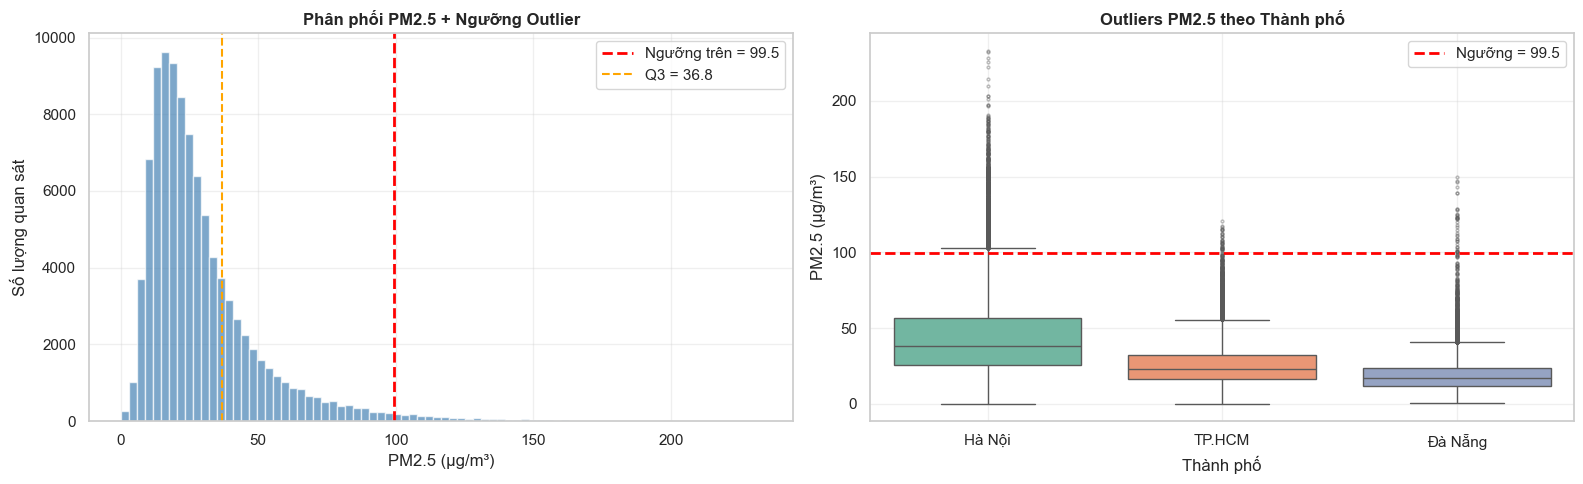

────────────────────────────────────────────────────────────
📊 Thống kê Outliers PM2.5 (Tukey 3×IQR):
   Q1 = 15.9 | Q3 = 36.8 | IQR = 20.9
   Ngưỡng trên:  99.5 µg/m³
   Ngưỡng dưới:  0.0 µg/m³

   Outlier phía trên: 1,837 điểm (1.86%)
   Outlier phía dưới: 0 điểm (0.00%)

   Phân bổ theo thành phố:
     • Hà Nội: 1,761 outliers (5.34%)
     • TP.HCM: 36 outliers (0.11%)
     • Đà Nẵng: 40 outliers (0.12%)


In [15]:
# ===== PHÂN TÍCH OUTLIERS =====
Q1  = df['pm25'].quantile(0.25)
Q3  = df['pm25'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR   # Tukey mở rộng cho time series
lower_fence = max(0, Q1 - 3 * IQR)   # PM2.5 không âm

outlier_high = df['pm25'] > upper_fence
outlier_low  = df['pm25'] < lower_fence

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram có đánh dấu ngưỡng
axes[0].hist(df['pm25'], bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(upper_fence, color='red',    linestyle='--', linewidth=2,
                label=f'Ngưỡng trên = {upper_fence:.1f}')
axes[0].axvline(Q3,          color='orange', linestyle='--', linewidth=1.5,
                label=f'Q3 = {Q3:.1f}')
axes[0].set_title('Phân phối PM2.5 + Ngưỡng Outlier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Số lượng quan sát')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot theo thành phố
sns.boxplot(data=df, x='city', y='pm25', palette='Set2', ax=axes[1],
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
axes[1].axhline(upper_fence, color='red', linestyle='--', linewidth=2,
                label=f'Ngưỡng = {upper_fence:.1f}')
axes[1].set_title('Outliers PM2.5 theo Thành phố', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thành phố')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Báo cáo chi tiết
print("─" * 60)
print(f"📊 Thống kê Outliers PM2.5 (Tukey 3×IQR):")
print(f"   Q1 = {Q1:.1f} | Q3 = {Q3:.1f} | IQR = {IQR:.1f}")
print(f"   Ngưỡng trên:  {upper_fence:.1f} µg/m³")
print(f"   Ngưỡng dưới:  {lower_fence:.1f} µg/m³")
print()
print(f"   Outlier phía trên: {outlier_high.sum():,} điểm "
      f"({100*outlier_high.mean():.2f}%)")
print(f"   Outlier phía dưới: {outlier_low.sum():,} điểm "
      f"({100*outlier_low.mean():.2f}%)")
print()
print("   Phân bổ theo thành phố:")
for city in df['city'].unique():
    sub = df[df['city'] == city]
    n   = (sub['pm25'] > upper_fence).sum()
    pct = 100 * n / len(sub)
    print(f"     • {city}: {n:,} outliers ({pct:.2f}%)")



### 📝 Nhận xét: Phân tích Outliers PM2.5

**Tham số phát hiện (Tukey 3×IQR):**
- Q3 = **36.8 µg/m³** | Ngưỡng trên = **99.5 µg/m³**
- Phân phối lệch phải mạnh → đuôi dài phía cao

#### Outliers theo thành phố
| Thành phố | Median | Giá trị max | Có outlier > 99.5? |
|---|---|---|---|
| **Hà Nội** | ~40 µg/m³ | ~220 µg/m³ | ✅ Có |
| **TP.HCM** | ~25 µg/m³ | ~200 µg/m³ | ✅ Có |
| **Đà Nẵng** | ~15 µg/m³ | ~150 µg/m³ | ✅ Có |

#### Giải thích khoa học
Các đột biến PM2.5 vượt 100 µg/m³ có thể do:
- 🔥 Cháy rừng / đốt rơm rạ theo mùa
- 🎆 Ô nhiễm cục bộ ngắn hạn (lễ hội, đốt pháo)
- 🏭 Sự cố công nghiệp bất thường
- 💨 Hiện tượng nghịch nhiệt cực đoan

#### ✅ Quyết định: **GIỮ outliers**

| Lý do | Chi tiết |
|---|---|
| **Vật lý có thật** | Đây là các sự kiện ô nhiễm thực tế, không phải lỗi đo |
| **Tỉ lệ thấp** | < 2% tổng dữ liệu → không gây bias đáng kể |
| **Mô hình phù hợp** | XGBoost robust với outliers, không cần loại bỏ |
| **Tính liên tục chuỗi** | Xóa điểm ngẫu nhiên trong time series gây data leakage |


### 2.6. Phân tích Biểu đồ Chuỗi thời gian và Tương quan
Khác hoàn toàn với AQI, đồ thị PM2.5 phản ánh độ chính xác vật lý tuyệt đối:
* **Dấu ấn Giao thông & Nghịch nhiệt:** Tại Hà Nội và TP.HCM, bụi mịn thấp nhất vào buổi trưa (nhờ mặt đất nóng giúp không khí khuếch tán) và tạo thành 2 "đỉnh ô nhiễm" vào giờ cao điểm đi làm (7-8h) và tan tầm (17-19h). Đỉnh ô nhiễm buổi tối kéo dài suốt đêm do Hiện tượng nghịch nhiệt bức xạ (Temperature Inversion) ép chặt khí thải sát mặt đất.
* **Quy luật Gió biển:** Đà Nẵng cực kỳ sạch vào ban đêm nhờ luồng gió biển (Sea breeze) thổi vào đất liền cuốn trôi bụi bẩn.
* **Đa cộng tuyến (Multicollinearity):** Ma trận Heatmap chỉ ra cột `factories_5km` và `factories_10km` có hệ số tương quan hoàn hảo (1.00). Giữ cả hai sẽ gây nhiễu trọng số cho các mô hình thống kê. 



## 3. Tiền xử lý Chốt hạ (Final Preprocessing)
Các hành động làm sạch trước khi đưa dữ liệu vào huấn luyện:
1. Loại bỏ cột `factories_10km` để giải quyết hiện tượng đa cộng tuyến.
2. Loại bỏ các cột `aqi`, `aqi_category` không còn sử dụng.
3. Nội suy tuyến tính để vá các khoảng khuyết (nếu có) và loại bỏ dòng trùng lặp.

In [16]:
# 1. Dọn dẹp cột thừa và gây nhiễu
cols_to_drop = ['aqi', 'aqi_category', 'factories_10km']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Xử lý Missing values bằng phương pháp nội suy tuyến tính (cho Time Series)
df_cleaned['pm25'] = df_cleaned['pm25'].interpolate(method='linear')

# 3. Loại bỏ các dòng trùng lặp (nếu có do lỗi API)
df_cleaned = df_cleaned.drop_duplicates()

# 4. Lưu lại tập dữ liệu sạch để dùng cho file huấn luyện mô hình
df_cleaned.to_csv('../data/processed/pm25_training_data.csv', index=False, encoding='utf-8-sig')

print("✅ Đã dọn dẹp và tiền xử lý thành công!")
print(f"Tổng số dòng sẵn sàng cho Machine Learning: {len(df_cleaned)}")
print("Dữ liệu đã được lưu tại: data/processed/pm25_training_data.csv")

✅ Đã dọn dẹp và tiền xử lý thành công!
Tổng số dòng sẵn sàng cho Machine Learning: 98907
Dữ liệu đã được lưu tại: data/processed/pm25_training_data.csv
